# Cross-Dataset Comparison — Tool Wear Prediction Project

This notebook synthesizes and compares all 3 datasets side-by-side:
- **PHM 2010** — Raw signals 50kHz, Inconel 718 milling, continuous VB labels
- **CNC Machining Energy** — Raw signals 500Hz, energy focus, no wear labels
- **CNC Turning (adorigueto)** — Tabular data, turning AISI H13, 3 discrete VBB levels

Sections:
1. Static property comparison (tables + radar chart)
2. Signal characteristics comparison
3. Feature space comparison
4. ML performance comparison
5. Dataset suitability scoring
6. Recommendations

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

DS_COLORS = {
    'PHM 2010':     '#1565C0',
    'CNC Energy':   '#2E7D32',
    'CNC Turning':  '#E65100',
}
print('✅ Setup ready')

✅ Setup ready


## 1. Static Dataset Properties Comparison

In [2]:
# --- Full comparison table ---
properties = {
    'Property': [
        'Process type', 'Machine', 'Workpiece material',
        'Data type', 'Sampling frequency', 'Number of channels',
        'Sensor types', 'Wear label', 'Wear resolution',
        'Labeled samples', 'Total raw size',
        'Cooling', 'Cutting param. variation',
        'Year', 'Academic standing',
    ],
    'PHM 2010': [
        'Milling (climb)', 'Röders Tech RFM760', 'Inconel 718',
        'Raw time series', '50,000 Hz', '7',
        'Dynamometer + Accelerometer + AE',
        'VB continuous (mm)', 'Continuous ~315 pts/tool',
        '~945 passes', '~50 GB',
        'None (dry)', 'Fixed (1 condition)',
        '2010', 'World benchmark, 500+ citations',
    ],
    'CNC Energy': [
        '5-axis milling', 'Spinner U5-630', 'Aluminium / PLA',
        'Raw time series', '500 Hz', '9+ per axis (×7 axes)',
        'Edge device (OPC-UA) — Power/Torque/Current',
        'None ❌', 'N/A',
        'None (no wear)', 'Several GB (JSON)',
        'None (dry)', 'Fixed (NC code per geometry)',
        '2025', 'Peer-reviewed (Data in Brief)',
    ],
    'CNC Turning': [
        'Turning (cylindrical)', 'ROMI E280', 'AISI H13 steel',
        'Tabular (aggregated)', 'N/A (per-pass mean)', '3',
        'Kistler dynamometer (forces only)',
        'VBB discrete (0/0.1/0.3 mm)', '3 discrete levels',
        '612 rows', '<1 MB',
        'Yes (Blaser Swisslube 8%)', 'Yes (Vc, f, ap varied)',
        '2022', 'Kaggle + Master thesis (ITA Brazil)',
    ],
}

df_prop = pd.DataFrame(properties).set_index('Property')
pd.set_option('display.max_colwidth', 55)
display(df_prop)

,PHM 2010,CNC Energy,CNC Turning
Property,,,
Process type,Milling (climb),5-axis milling,Turning (cylindrical)
Machine,Röders Tech RFM760,Spinner U5-630,ROMI E280
Workpiece material,Inconel 718,Aluminium / PLA,AISI H13 steel
Data type,Raw time series,Raw time series,Tabular (aggregated)
Sampling frequency,"50,000 Hz",500 Hz,N/A (per-pass mean)
Number of channels,7,9+ per axis (×7 axes),3
Sensor types,Dynamometer + Accelerometer + AE,Edge device (OPC-UA) — Power/Torque/Current,Kistler dynamometer (forces only)
Wear label,VB continuous (mm),None ❌,VBB discrete (0/0.1/0.3 mm)
Wear resolution,Continuous ~315 pts/tool,N/A,3 discrete levels


## 2. Radar Chart — Multi-Criteria Comparison

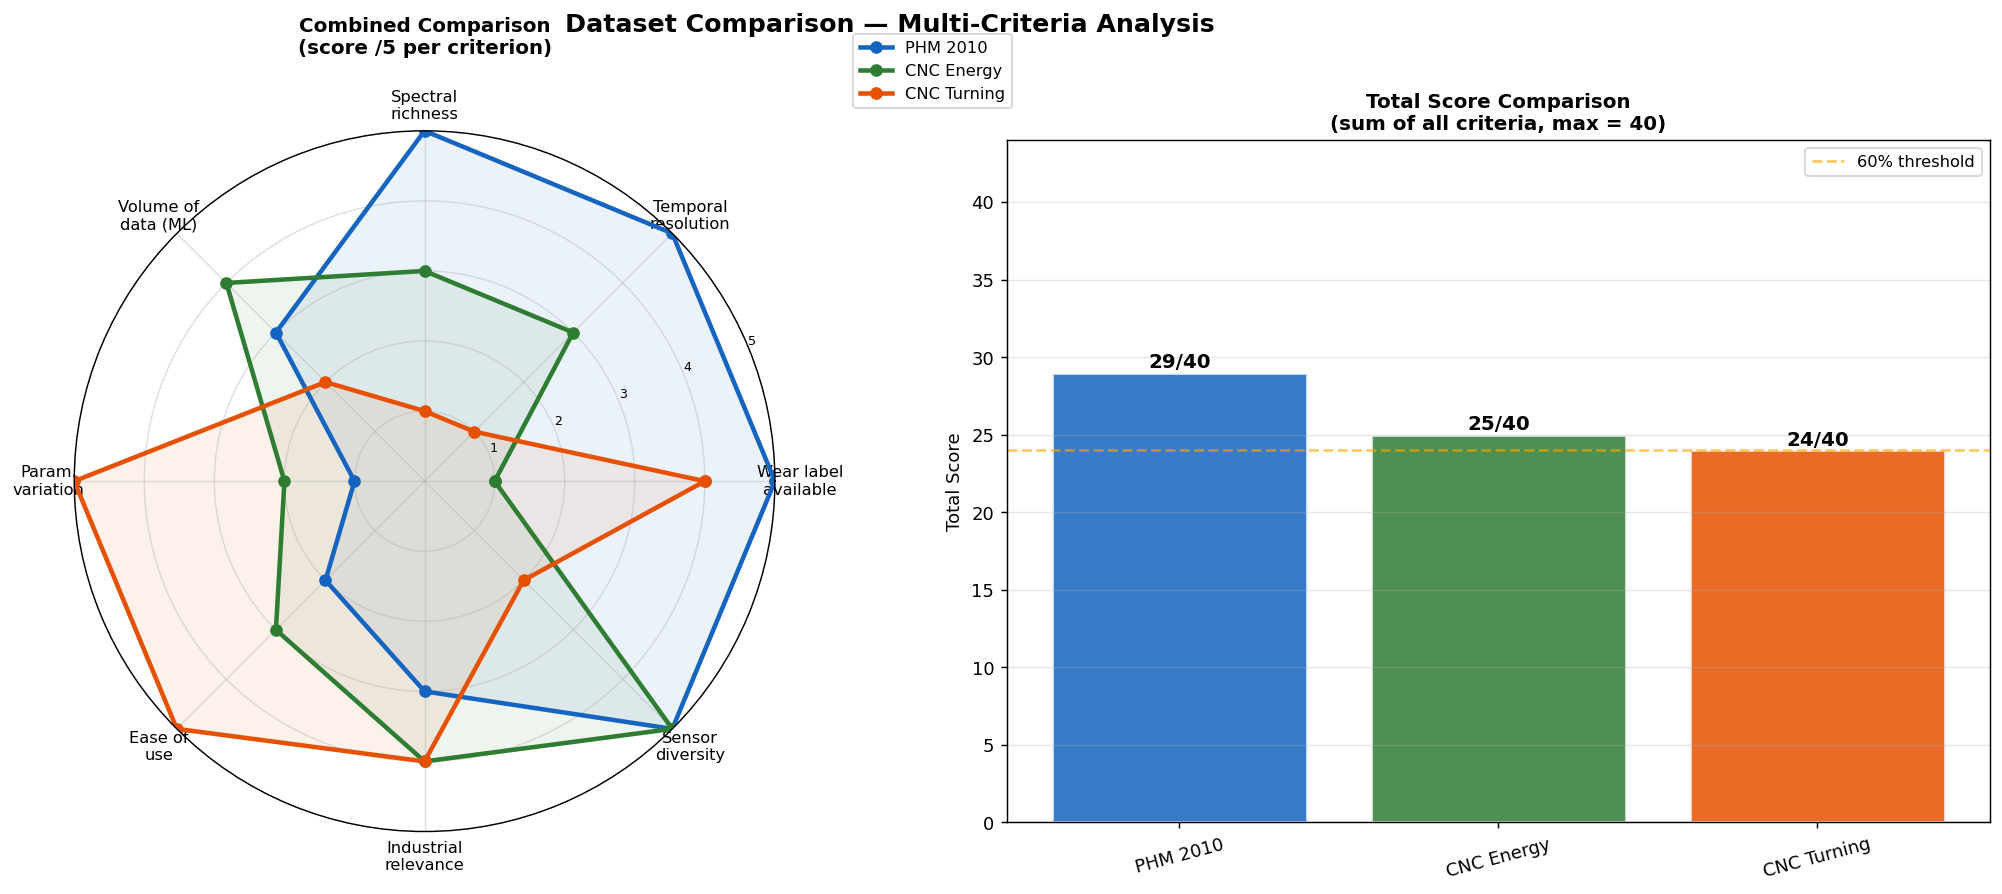

In [3]:
criteria = [
    'Wear label\navailable',
    'Temporal\nresolution',
    'Spectral\nrichness',
    'Volume of\ndata (ML)',
    'Param.\nvariation',
    'Ease of\nuse',
    'Industrial\nrelevance',
    'Sensor\ndiversity',
]

scores = {
    'PHM 2010':   [5, 5, 5, 3, 1, 2, 3, 5],
    'CNC Energy': [1, 3, 3, 4, 2, 3, 4, 5],
    'CNC Turning':[4, 1, 1, 2, 5, 5, 4, 2],
}

N = len(criteria)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                          subplot_kw=dict(polar=True))

# Individual radar per dataset
for ax_idx, (ds_name, vals) in enumerate(scores.items()):
    pass  # will use combined plot

# Combined radar
ax = axes[0]
for ds_name, vals in scores.items():
    v = vals + vals[:1]
    ax.plot(angles, v, 'o-', linewidth=2.5, label=ds_name, color=DS_COLORS[ds_name])
    ax.fill(angles, v, alpha=0.08, color=DS_COLORS[ds_name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, size=9)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], size=7)
ax.set_title('Combined Comparison\n(score /5 per criterion)',
              fontsize=11, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(True, alpha=0.4)

# Stacked score bar chart
ax2 = axes[1]
ax2.remove()
ax2 = fig.add_axes([0.55, 0.12, 0.42, 0.75])

total_scores = {ds: sum(v) for ds, v in scores.items()}
ds_names  = list(total_scores.keys())
ds_totals = list(total_scores.values())
bars = ax2.bar(ds_names, ds_totals,
                color=[DS_COLORS[d] for d in ds_names],
                edgecolor='white', linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, ds_totals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val}/{N*5}', ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Total Score Comparison\n(sum of all criteria, max = 40)',
               fontsize=11, fontweight='bold')
ax2.set_ylabel('Total Score')
ax2.set_ylim(0, N * 5 + 4)
ax2.axhline(N * 5 * 0.6, color='orange', linestyle='--', alpha=0.6, label='60% threshold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Dataset Comparison — Multi-Criteria Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('comparison_radar_and_score.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Signal Characteristics Comparison

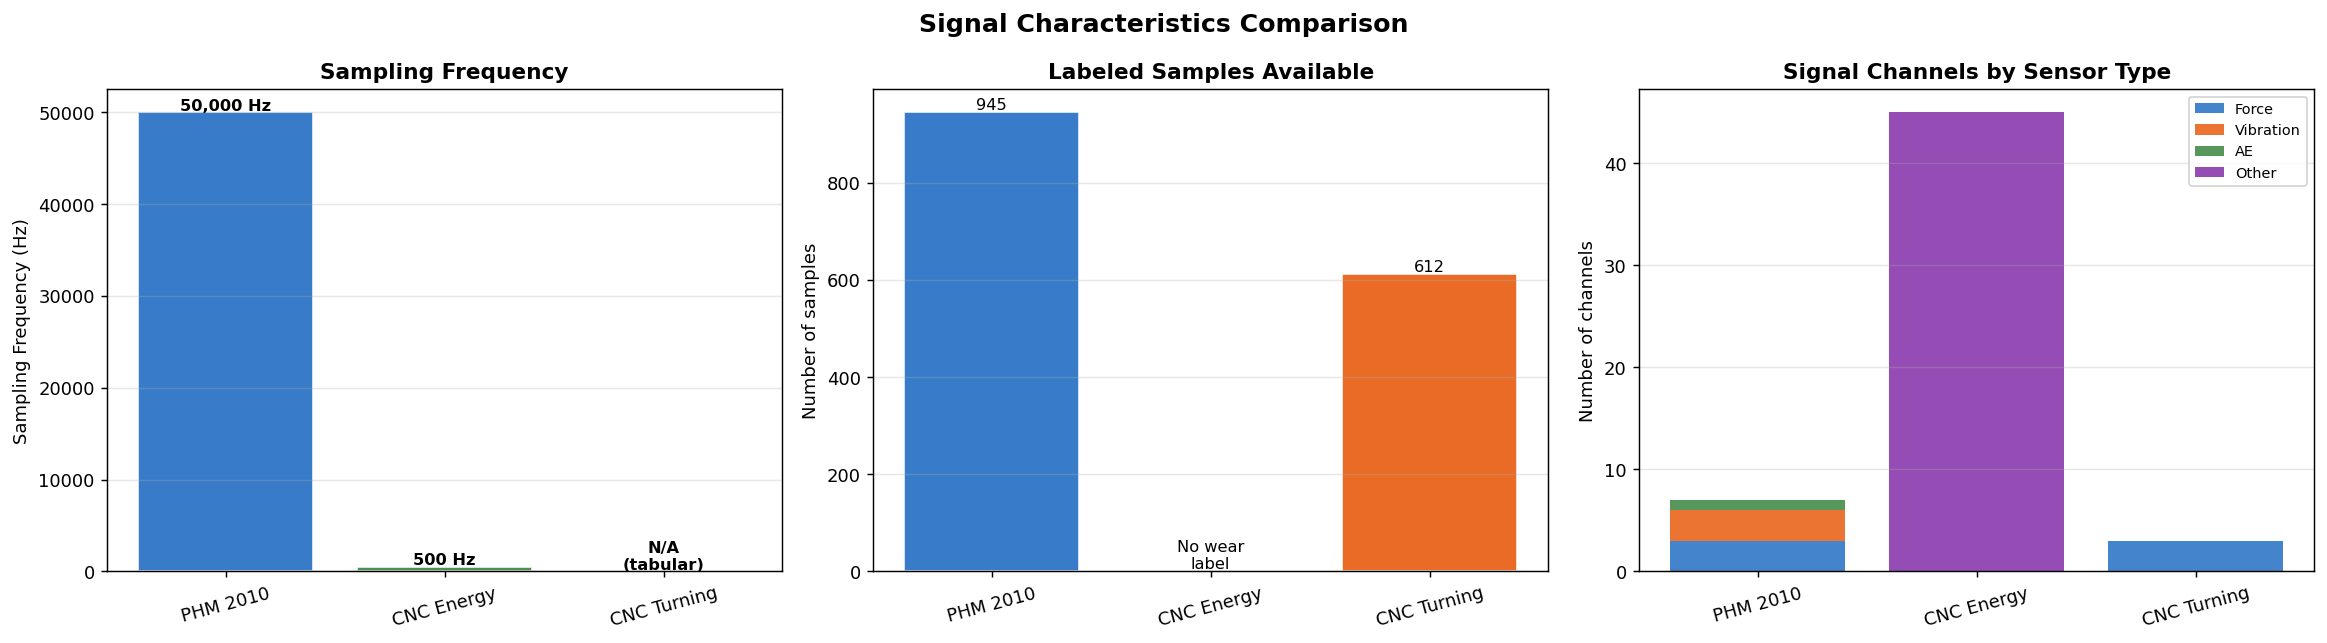

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 3a. Sampling frequency comparison ---
datasets  = ['PHM 2010', 'CNC Energy', 'CNC Turning']
fs_values = [50000, 500, None]
nyquist   = [f/2 if f else 0 for f in fs_values]

x_pos = [0, 1, 2]
bars_fs = axes[0].bar(x_pos, [f or 0 for f in fs_values],
                        color=[DS_COLORS[d] for d in datasets],
                        edgecolor='white', alpha=0.85)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(datasets, rotation=15)
axes[0].set_ylabel('Sampling Frequency (Hz)')
axes[0].set_title('Sampling Frequency', fontweight='bold')
for bar, val in zip(bars_fs, [f or 0 for f in fs_values]):
    label = f'{val:,} Hz' if val > 0 else 'N/A\n(tabular)'
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 200, label,
                  ha='center', fontsize=9, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# --- 3b. Data volume (labeled samples) ---
volumes = {'PHM 2010': 945, 'CNC Energy': 0, 'CNC Turning': 612}
axes[1].bar(volumes.keys(), volumes.values(),
             color=[DS_COLORS[d] for d in volumes.keys()],
             edgecolor='white', alpha=0.85)
axes[1].set_title('Labeled Samples Available', fontweight='bold')
axes[1].set_ylabel('Number of samples')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')
for ds, vol in volumes.items():
    label = str(vol) if vol > 0 else 'No wear\nlabel'
    axes[1].text(list(volumes.keys()).index(ds), vol + 5, label,
                  ha='center', fontsize=9)

# --- 3c. Number of signal channels ---
channels = {'PHM 2010': 7, 'CNC Energy': 45, 'CNC Turning': 3}
ch_types = {
    'PHM 2010':   {'Force': 3, 'Vibration': 3, 'AE': 1, 'Other': 0},
    'CNC Energy': {'Force': 0, 'Vibration': 0, 'AE': 0, 'Other': 45},
    'CNC Turning':{'Force': 3, 'Vibration': 0, 'AE': 0, 'Other': 0},
}
ch_colors = {'Force': '#1565C0', 'Vibration': '#E65100', 'AE': '#2E7D32', 'Other': '#7B1FA2'}
bottom = np.zeros(3)
for sensor_type, color in ch_colors.items():
    vals = [ch_types[d][sensor_type] for d in datasets]
    axes[2].bar(range(3), vals, bottom=bottom, label=sensor_type, color=color, alpha=0.8)
    bottom += np.array(vals)
axes[2].set_xticks(range(3)); axes[2].set_xticklabels(datasets, rotation=15)
axes[2].set_title('Signal Channels by Sensor Type', fontweight='bold')
axes[2].set_ylabel('Number of channels')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Signal Characteristics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_signal_characteristics.png', dpi=150)
plt.show()

## 4. Feature Extractability Heatmap

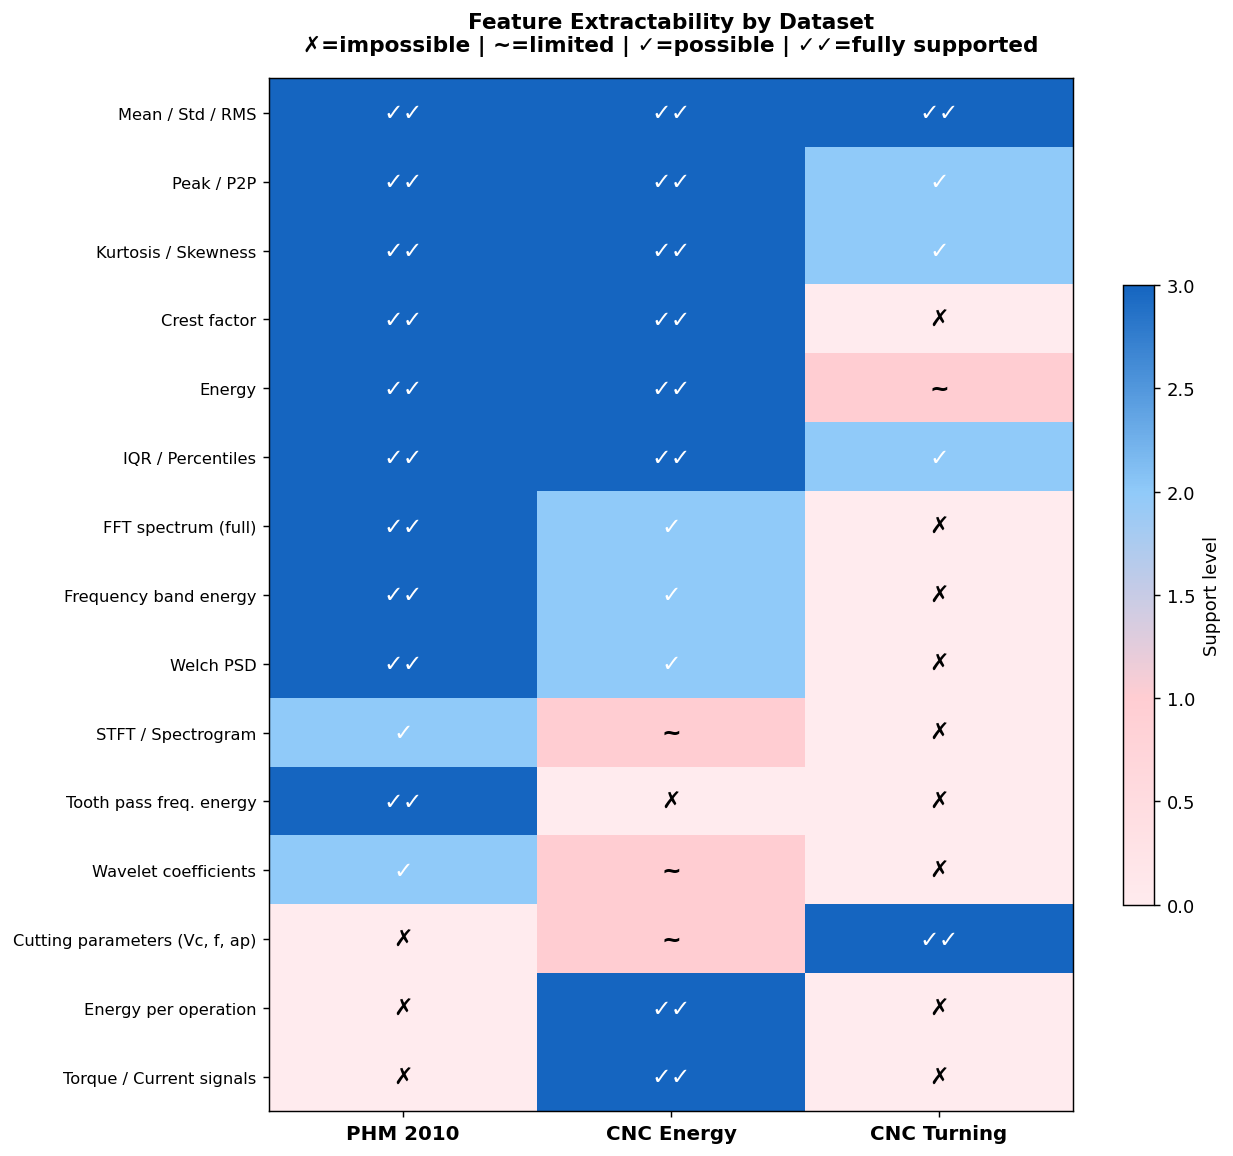

In [5]:
features_matrix = {
    'Feature type': [
        'Mean / Std / RMS', 'Peak / P2P', 'Kurtosis / Skewness',
        'Crest factor', 'Energy', 'IQR / Percentiles',
        'FFT spectrum (full)', 'Frequency band energy',
        'Welch PSD', 'STFT / Spectrogram',
        'Tooth pass freq. energy', 'Wavelet coefficients',
        'Cutting parameters (Vc, f, ap)', 'Energy per operation',
        'Torque / Current signals',
    ],
    'PHM 2010':   [3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 0, 0, 0],
    'CNC Energy': [3, 3, 3, 3, 3, 3, 2, 2, 2, 1, 0, 1, 1, 3, 3],
    'CNC Turning':[3, 2, 2, 0, 1, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0],
}
# 0=not possible, 1=limited, 2=possible, 3=fully supported

df_feat_matrix = pd.DataFrame(features_matrix).set_index('Feature type')

fig, ax = plt.subplots(figsize=(10, 9))
cmap = LinearSegmentedColormap.from_list('feat', ['#FFEBEE','#FFCDD2','#90CAF9','#1565C0'])
im = ax.imshow(df_feat_matrix.values, cmap=cmap, aspect='auto', vmin=0, vmax=3)

ax.set_xticks(range(3))
ax.set_xticklabels(df_feat_matrix.columns, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(df_feat_matrix)))
ax.set_yticklabels(df_feat_matrix.index, fontsize=9)

for i in range(len(df_feat_matrix)):
    for j in range(3):
        val = df_feat_matrix.values[i, j]
        labels = {0: '✗', 1: '~', 2: '✓', 3: '✓✓'}
        color  = 'white' if val >= 2 else 'black'
        ax.text(j, i, labels[val], ha='center', va='center',
                 fontsize=13, color=color, fontweight='bold')

ax.set_title('Feature Extractability by Dataset\n'
              '✗=impossible | ~=limited | ✓=possible | ✓✓=fully supported',
              fontsize=12, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, shrink=0.6, label='Support level')
plt.tight_layout()
plt.savefig('comparison_feature_heatmap.png', dpi=150)
plt.show()

## 5. ML Performance Comparison

In [6]:
# Load results from individual notebooks if available
# Otherwise use placeholder structure for manual fill-in

try:
    df_phm_feat = pd.read_csv('phm2010_features.csv')
    phm_loaded = True
    print(f'✅ PHM 2010 features loaded: {df_phm_feat.shape}')
except FileNotFoundError:
    phm_loaded = False
    print('⚠️ phm2010_features.csv not found — run analysis_PHM2010.ipynb first')

# Build results table (fill manually or load from individual notebooks)
ml_results = pd.DataFrame([
    # PHM 2010
    {'Dataset': 'PHM 2010', 'Test condition': 'LOTO → C6', 'Model': 'Random Forest',
     'Target': 'VB (mm)', 'MAE': None, 'RMSE': None, 'R2': None},
    {'Dataset': 'PHM 2010', 'Test condition': 'LOTO → C4', 'Model': 'Random Forest',
     'Target': 'VB (mm)', 'MAE': None, 'RMSE': None, 'R2': None},
    {'Dataset': 'PHM 2010', 'Test condition': 'LOTO → C1', 'Model': 'Random Forest',
     'Target': 'VB (mm)', 'MAE': None, 'RMSE': None, 'R2': None},
    # CNC Turning
    {'Dataset': 'CNC Turning', 'Test condition': '5-Fold CV', 'Model': 'Random Forest',
     'Target': 'Ra (µm)', 'MAE': None, 'RMSE': None, 'R2': None},
    {'Dataset': 'CNC Turning', 'Test condition': '5-Fold CV', 'Model': 'Gradient Boosting',
     'Target': 'Ra (µm)', 'MAE': None, 'RMSE': None, 'R2': None},
    {'Dataset': 'CNC Turning', 'Test condition': '5-Fold CV', 'Model': 'Linear Regression',
     'Target': 'Ra (µm)', 'MAE': None, 'RMSE': None, 'R2': None},
])

print('\n📊 ML Results table (fill with actual values after running individual notebooks):')
display(ml_results)

✅ PHM 2010 features loaded: (945, 200)

📊 ML Results table (fill with actual values after running individual notebooks):


,Dataset,Test condition,Model,Target,MAE,RMSE,R2
0,PHM 2010,LOTO → C6,Random Forest,VB (mm),None,None,None
1,PHM 2010,LOTO → C4,Random Forest,VB (mm),None,None,None
2,PHM 2010,LOTO → C1,Random Forest,VB (mm),None,None,None
3,CNC Turning,5-Fold CV,Random Forest,Ra (µm),None,None,None
4,CNC Turning,5-Fold CV,Gradient Boosting,Ra (µm),None,None,None
5,CNC Turning,5-Fold CV,Linear Regression,Ra (µm),None,None,None


## 6. Wear Label Quality Comparison

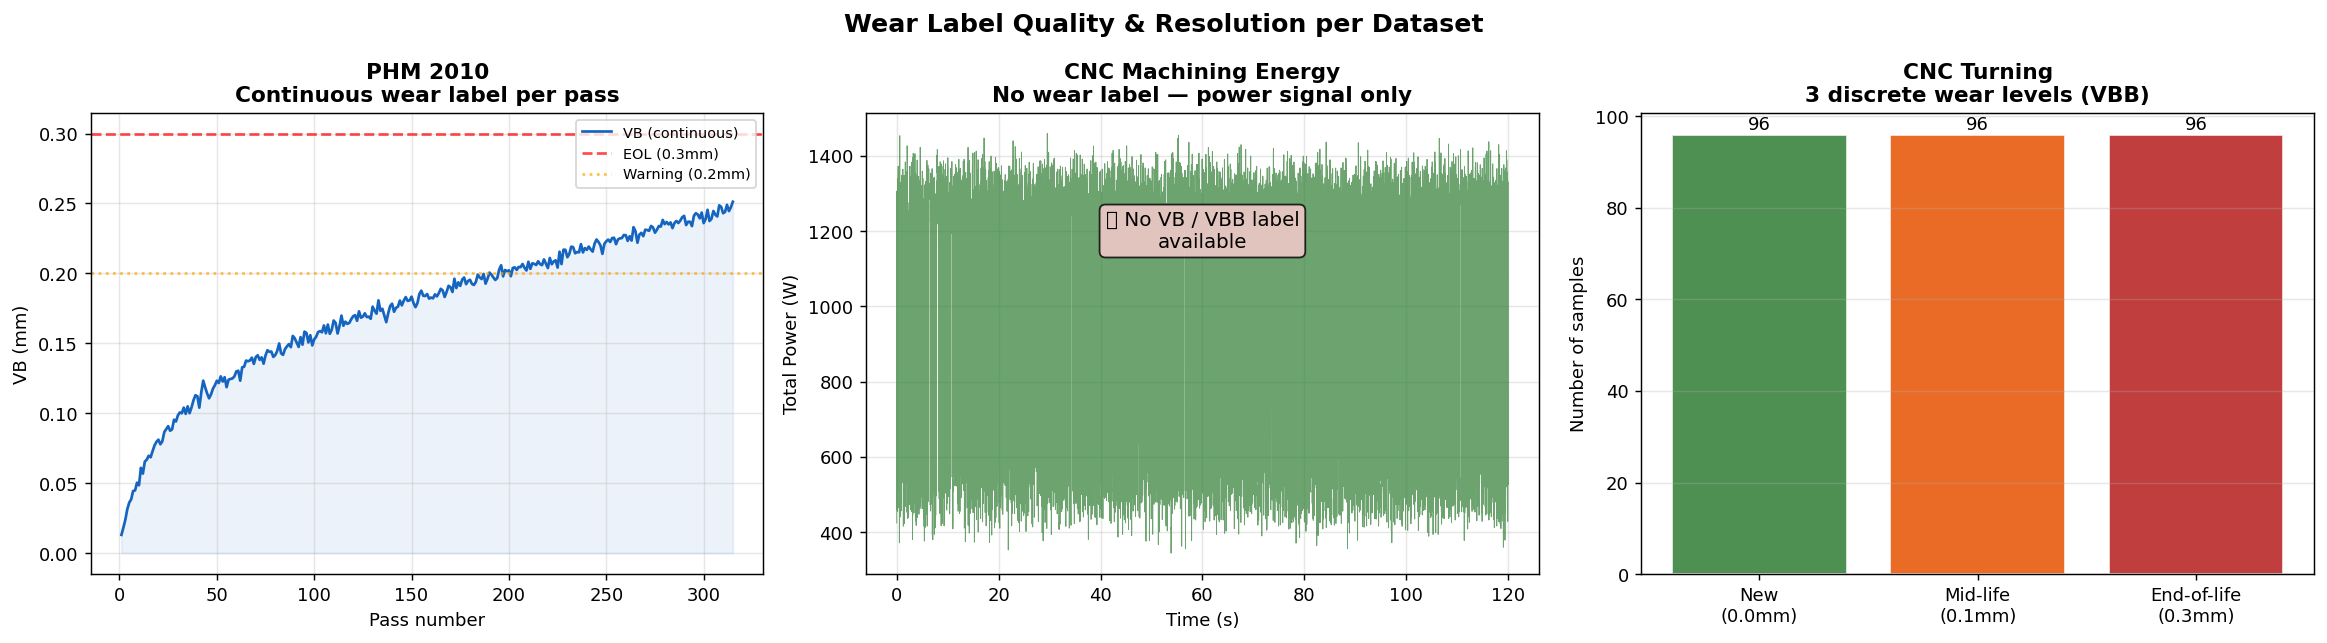

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- PHM 2010: continuous wear curve (simulated for illustration) ---
passes = np.arange(1, 316)
# Typical wear curve: initial rapid wear → stable → accelerated
vb_sim = 0.05 * np.log1p(passes/5) + 0.001 * (passes/50)**2
vb_sim += np.random.normal(0, 0.003, len(passes))
vb_sim = np.clip(vb_sim, 0, None)

axes[0].plot(passes, vb_sim, color='#1565C0', linewidth=1.5, label='VB (continuous)')
axes[0].axhline(0.3, color='red',    linestyle='--', alpha=0.7, label='EOL (0.3mm)')
axes[0].axhline(0.2, color='orange', linestyle=':',  alpha=0.7, label='Warning (0.2mm)')
axes[0].fill_between(passes, 0, vb_sim, alpha=0.08, color='#1565C0')
axes[0].set_xlabel('Pass number'); axes[0].set_ylabel('VB (mm)')
axes[0].set_title('PHM 2010\nContinuous wear label per pass', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# --- CNC Energy: no label ---
t_sim = np.linspace(0, 120, 5000)
power_sim = 500 + 800 * (np.random.rand(5000) > 0.4) + np.random.normal(0, 50, 5000)
axes[1].plot(t_sim, power_sim, color='#2E7D32', linewidth=0.5, alpha=0.7)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Total Power (W)')
axes[1].set_title('CNC Machining Energy\nNo wear label — power signal only', fontweight='bold')
axes[1].text(60, 1200, '❌ No VB / VBB label\navailable',
              ha='center', va='center', fontsize=11,
              bbox=dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.8))
axes[1].grid(True, alpha=0.3)

# --- CNC Turning: 3 discrete levels ---
wear_levels = [0.0, 0.1, 0.3]
n_samples   = [96, 96, 96]  # approximate
level_labels = ['New\n(0.0mm)', 'Mid-life\n(0.1mm)', 'End-of-life\n(0.3mm)']
level_colors = ['#2E7D32', '#E65100', '#B71C1C']
bars = axes[2].bar(level_labels, n_samples, color=level_colors, edgecolor='white', alpha=0.85)
axes[2].set_ylabel('Number of samples')
axes[2].set_title('CNC Turning\n3 discrete wear levels (VBB)', fontweight='bold')
for bar, n in zip(bars, n_samples):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                  str(n), ha='center', fontsize=10)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Wear Label Quality & Resolution per Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_wear_labels.png', dpi=150)
plt.show()

## 7. Pros and Cons Summary Visualization

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

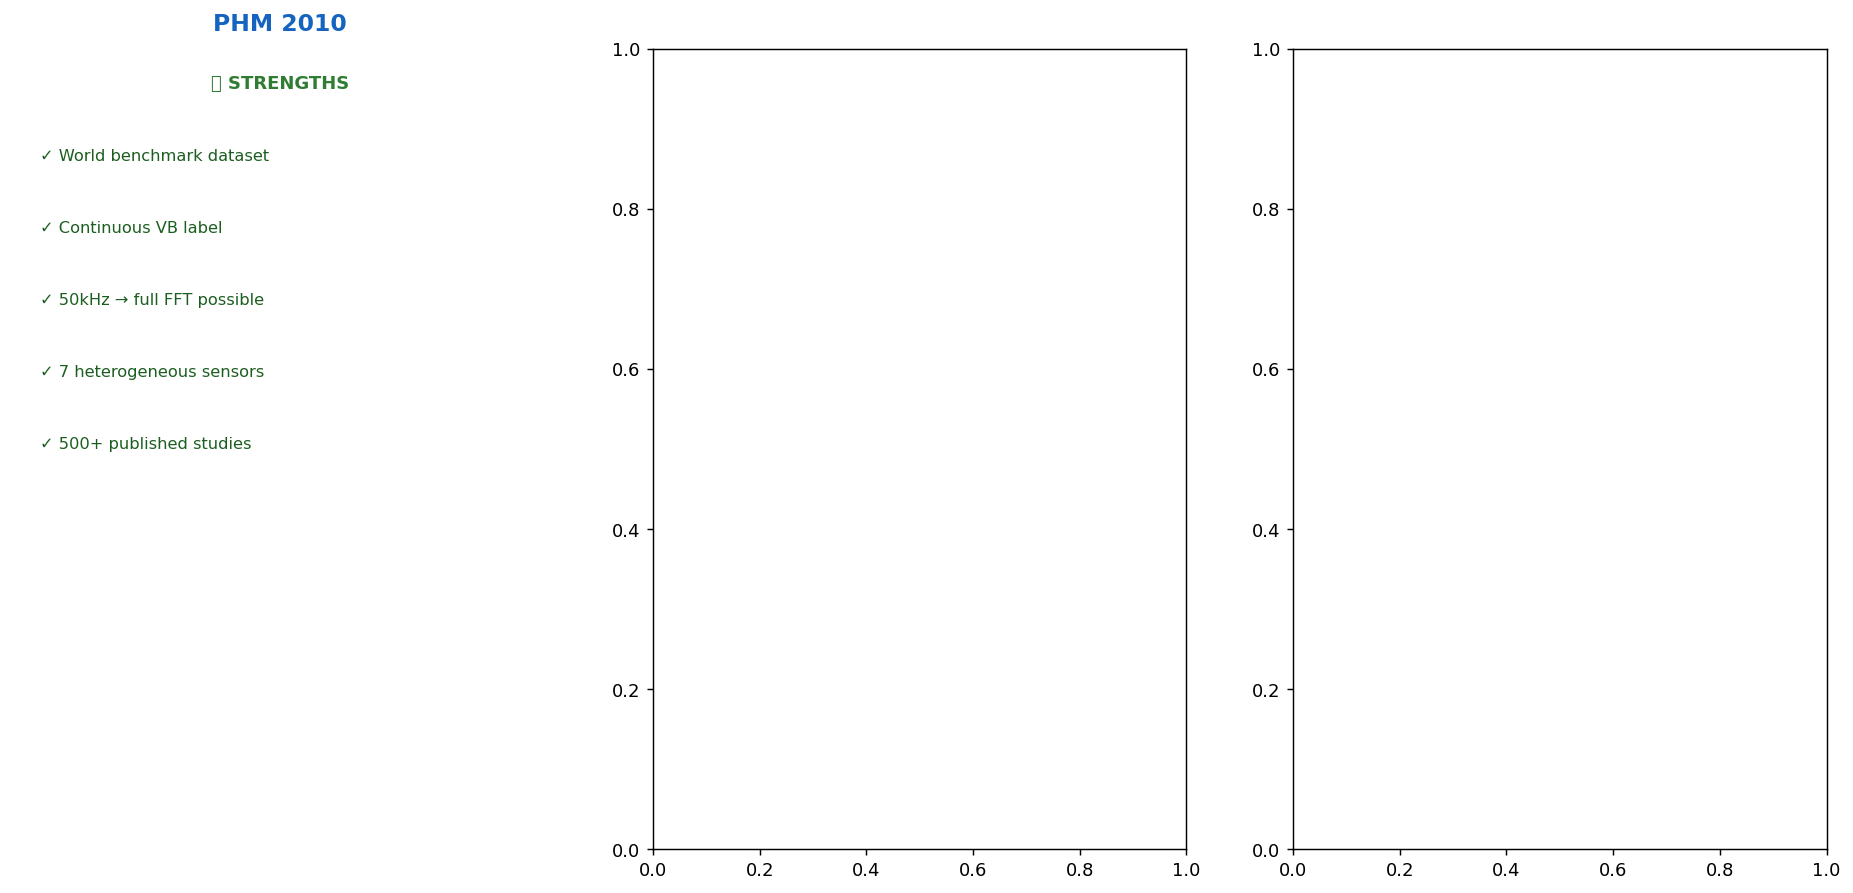

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

summary_data = {
    'PHM 2010': {
        'pros': [
            '✓ World benchmark dataset',
            '✓ Continuous VB label',
            '✓ 50kHz → full FFT possible',
            '✓ 7 heterogeneous sensors',
            '✓ 500+ published studies',
        ],
        'cons': [
            '✗ Only 3 labeled tools',
            '✗ Single cutting condition',
            '✗ Inconel 718 (aerospace only)',
            '✗ Offline wear measurement',
            '✗ ~50 GB total size',
        ],
        'color': '#1565C0',
    },
    'CNC\nEnergy': {
        'pros': [
            '✓ High temporal detail (2ms)',
            '✓ Multi-material (Al + PLA)',
            '✓ Full energy signals',
            '✓ Peer-reviewed 2025',
            '✓ NC code synchronized',
        ],
        'cons': [
            '✗ No tool wear label',
            '✗ Only 4 geometries',
            '✗ No cooling (non-industrial)',
            '✗ 1 machine only',
            '✗ Large JSON files',
        ],
        'color': '#2E7D32',
    },
    'CNC\nTurning': {
        'pros': [
            '✓ Cutting params varied',
            '✓ Easy to use (tabular)',
            '✓ Realistic conditions (coolant)',
            '✓ Ra + VBB both available',
            '✓ Minimal preprocessing',
        ],
        'cons': [
            '✗ Only 3 discrete wear levels',
            '✗ Artificially worn tools',
            '✗ No spectral analysis possible',
            '✗ 612 rows (small dataset)',
            '✗ Turning ≠ Milling',
        ],
        'color': '#E65100',
    },
}

for ax, (ds_name, data) in zip(axes, summary_data.items()):
    ax.axis('off')
    ax.set_title(ds_name.replace('\n', ' '), fontsize=13, fontweight='bold',
                  color=data['color'], pad=10)

    y_start = 0.95
    ax.text(0.5, y_start, '✅ STRENGTHS', transform=ax.transAxes,
             ha='center', fontsize=10, fontweight='bold', color='#2E7D32')
    for i, pro in enumerate(data['pros']):
        ax.text(0.05, y_start - 0.09 * (i+1), pro, transform=ax.transAxes,
                 fontsize=9, color='#1B5E20')

    ax.plot([0.05, 0.95], [0.45, 0.45], color='gray',
            linewidth=0.8, transform=ax.transAxes)

    ax.text(0.5, 0.42, '⚠️ LIMITATIONS', transform=ax.transAxes,
             ha='center', fontsize=10, fontweight='bold', color='#B71C1C')
    for i, con in enumerate(data['cons']):
        ax.text(0.05, 0.35 - 0.08 * i, con, transform=ax.transAxes,
                 fontsize=9, color='#7F0000')

    rect = plt.Rectangle((0, 0), 1, 1, fill=False,
                            edgecolor=data['color'], linewidth=2, transform=ax.transAxes)
    ax.add_patch(rect)

plt.suptitle('Dataset Pros & Cons Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison_pros_cons.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Column Mapping & Feature Harmonization Analysis

In [ ]:
# Define column equivalence mapping across datasets
column_mapping = {
    'Force X': {
        'PHM 2010': 'force_x',
        'CNC Energy': 'Power_X (indirect)',
        'CNC Turning': 'Fx',
        'category': 'Force',
        'unit': 'N',
    },
    'Force Y': {
        'PHM 2010': 'force_y',
        'CNC Energy': 'Power_Y (indirect)',
        'CNC Turning': 'Fy',
        'category': 'Force',
        'unit': 'N',
    },
    'Force Z': {
        'PHM 2010': 'force_z',
        'CNC Energy': 'Power_Z (indirect)',
        'CNC Turning': 'Fz',
        'category': 'Force',
        'unit': 'N',
    },
    'Vibration X': {
        'PHM 2010': 'vib_x',
        'CNC Energy': '—',
        'CNC Turning': '—',
        'category': 'Vibration',
        'unit': 'g',
    },
    'Vibration Y': {
        'PHM 2010': 'vib_y',
        'CNC Energy': '—',
        'CNC Turning': '—',
        'category': 'Vibration',
        'unit': 'g',
    },
    'Vibration Z': {
        'PHM 2010': 'vib_z',
        'CNC Energy': '—',
        'CNC Turning': '—',
        'category': 'Vibration',
        'unit': 'g',
    },
    'Acoustic Emission': {
        'PHM 2010': 'ae',
        'CNC Energy': '—',
        'CNC Turning': '—',
        'category': 'Acoustic',
        'unit': 'V',
    },
    'Power/Torque X': {
        'PHM 2010': '—',
        'CNC Energy': 'Power_X / Torque_X',
        'CNC Turning': '—',
        'category': 'Power',
        'unit': 'W / Nm',
    },
    'Power/Torque Y': {
        'PHM 2010': '—',
        'CNC Energy': 'Power_Y / Torque_Y',
        'CNC Turning': '—',
        'category': 'Power',
        'unit': 'W / Nm',
    },
    'Power/Torque Z': {
        'PHM 2010': '—',
        'CNC Energy': 'Power_Z / Torque_Z',
        'CNC Turning': '—',
        'category': 'Power',
        'unit': 'W / Nm',
    },
    'Spindle Power/Speed': {
        'PHM 2010': '—',
        'CNC Energy': 'Power_S / Speed_S',
        'CNC Turning': '—',
        'category': 'Spindle',
        'unit': 'W / RPM',
    },
    'Cutting Speed (Vc)': {
        'PHM 2010': '— (fixed)',
        'CNC Energy': '— (NC code)',
        'CNC Turning': 'Vc',
        'category': 'Process param',
        'unit': 'm/min',
    },
    'Feed Rate (f)': {
        'PHM 2010': '— (fixed)',
        'CNC Energy': 'F (NC code)',
        'CNC Turning': 'f',
        'category': 'Process param',
        'unit': 'mm/rev or mm/min',
    },
    'Depth of Cut (ap)': {
        'PHM 2010': '— (fixed)',
        'CNC Energy': '— (NC code)',
        'CNC Turning': 'ap',
        'category': 'Process param',
        'unit': 'mm',
    },
    'Tool Wear (VB/VBB)': {
        'PHM 2010': 'vb (continuous)',
        'CNC Energy': '—',
        'CNC Turning': 'VBB (3 levels)',
        'category': 'Target label',
        'unit': 'mm',
    },
    'Surface Roughness (Ra)': {
        'PHM 2010': '—',
        'CNC Energy': '—',
        'CNC Turning': 'Ra',
        'category': 'Target label',
        'unit': 'µm',
    },
}

df_mapping = pd.DataFrame(column_mapping).T
print('📋 Column Equivalence Mapping Across Datasets:\n')
display(df_mapping)

### 8.1 Visual Column Mapping (Sankey-style Diagram)

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

# Dataset positions
ds_x = {'PHM 2010': 0.1, 'CNC Energy': 0.5, 'CNC Turning': 0.9}
ds_y_start = 0.95
ds_colors_map = DS_COLORS

# Column categories and their y-positions
categories = {
    'Force signals': {'color': '#1565C0', 'y': 0.80, 'members': ['Force X', 'Force Y', 'Force Z']},
    'Vibration signals': {'color': '#E65100', 'y': 0.60, 'members': ['Vibration X', 'Vibration Y', 'Vibration Z']},
    'Acoustic': {'color': '#2E7D32', 'y': 0.50, 'members': ['Acoustic Emission']},
    'Power/Energy': {'color': '#7B1FA2', 'y': 0.40, 'members': ['Power/Torque X', 'Power/Torque Y', 'Power/Torque Z', 'Spindle Power/Speed']},
    'Process params': {'color': '#F57C00', 'y': 0.25, 'members': ['Cutting Speed (Vc)', 'Feed Rate (f)', 'Depth of Cut (ap)']},
    'Target labels': {'color': '#C62828', 'y': 0.10, 'members': ['Tool Wear (VB/VBB)', 'Surface Roughness (Ra)']},
}

# Draw dataset boxes
for ds_name, x_pos in ds_x.items():
    rect = mpatches.FancyBboxPatch((x_pos - 0.08, ds_y_start - 0.04), 0.16, 0.06,
                                    boxstyle='round,pad=0.01',
                                    facecolor=ds_colors_map[ds_name], edgecolor='white',
                                    linewidth=2, alpha=0.9, transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(x_pos, ds_y_start - 0.01, ds_name, ha='center', va='center',
             fontsize=12, fontweight='bold', color='white', transform=ax.transAxes)

# Draw connections for each feature
for feat_name, feat_info in column_mapping.items():
    cat_info = next((v for k, v in categories.items() if feat_name in v['members']), None)
    if not cat_info: continue

    y_base = cat_info['y']
    color = cat_info['color']
    offset = (cat_info['members'].index(feat_name) - len(cat_info['members'])/2) * 0.025

    y_pos = y_base + offset

    # For each dataset, draw connection if column exists
    for ds_name, x_pos in ds_x.items():
        col_val = feat_info.get(ds_name, '—')
        if col_val != '—':
            # Draw node
            circle = plt.Circle((x_pos, y_pos), 0.015, color=color,
                                 edgecolor='white', linewidth=1.5, zorder=3, transform=ax.transAxes)
            ax.add_patch(circle)

            # Draw horizontal line connecting datasets with same feature
            other_datasets = [ds for ds in ds_x.keys() if ds != ds_name and feat_info.get(ds, '—') != '—']
            for other_ds in other_datasets:
                if ds_x[other_ds] > x_pos:  # Only draw right connections to avoid duplicates
                    ax.plot([x_pos + 0.015, ds_x[other_ds] - 0.015], [y_pos, y_pos],
                             color=color, linewidth=2, alpha=0.3, zorder=1, transform=ax.transAxes)

# Add category labels on the left
for cat_name, cat_info in categories.items():
    ax.text(0.01, cat_info['y'], cat_name, ha='left', va='center',
             fontsize=10, fontweight='bold', color=cat_info['color'], transform=ax.transAxes)

# Legend
legend_items = [
    mpatches.Patch(color=cat_info['color'], label=cat_name)
    for cat_name, cat_info in categories.items()
]
ax.legend(handles=legend_items, loc='lower center', ncol=3, fontsize=9,
           frameon=True, fancybox=True)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Column Mapping Across Datasets\n(Horizontal lines show equivalent/similar columns)',
              fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('comparison_column_mapping.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Unique vs Shared Features Analysis

In [ ]:
# Count features per dataset
feature_presence = {}
for feat_name, feat_info in column_mapping.items():
    presence = []
    for ds in ['PHM 2010', 'CNC Energy', 'CNC Turning']:
        if feat_info.get(ds, '—') != '—':
            presence.append(ds)
    feature_presence[feat_name] = presence

# Categorize
unique_to_phm = [f for f, ds_list in feature_presence.items() if ds_list == ['PHM 2010']]
unique_to_energy = [f for f, ds_list in feature_presence.items() if ds_list == ['CNC Energy']]
unique_to_turning = [f for f, ds_list in feature_presence.items() if ds_list == ['CNC Turning']]
shared_all_three = [f for f, ds_list in feature_presence.items() if len(ds_list) == 3]
shared_two = [f for f, ds_list in feature_presence.items() if len(ds_list) == 2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Venn-style bar chart
categories_venn = {
    f'Shared (all 3)\n({len(shared_all_three)})': len(shared_all_three),
    f'Shared (2 DS)\n({len(shared_two)})': len(shared_two),
    f'PHM only\n({len(unique_to_phm)})': len(unique_to_phm),
    f'Energy only\n({len(unique_to_energy)})': len(unique_to_energy),
    f'Turning only\n({len(unique_to_turning)})': len(unique_to_turning),
}
colors_venn = ['#4CAF50', '#FFC107', '#1565C0', '#2E7D32', '#E65100']
bars = axes[0].bar(categories_venn.keys(), categories_venn.values(),
                    color=colors_venn, edgecolor='white', alpha=0.85)
axes[0].set_title('Feature Sharing Across Datasets', fontweight='bold')
axes[0].set_ylabel('Number of features')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3, axis='y')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.1,
                      int(h), ha='center', fontweight='bold')

# List shared features
axes[1].axis('off')
text_y = 0.95
axes[1].text(0.5, text_y, '📊 Feature Category Breakdown', ha='center', va='top',
              fontsize=12, fontweight='bold', transform=axes[1].transAxes)
text_y -= 0.08

if shared_all_three:
    axes[1].text(0.05, text_y, '✅ Shared by all 3 datasets:', ha='left', va='top',
                  fontsize=10, fontweight='bold', color='#4CAF50', transform=axes[1].transAxes)
    text_y -= 0.05
    for feat in shared_all_three:
        axes[1].text(0.1, text_y, f'• {feat}', ha='left', va='top',
                      fontsize=9, transform=axes[1].transAxes)
        text_y -= 0.04

text_y -= 0.02
if shared_two:
    axes[1].text(0.05, text_y, '⚡ Shared by 2 datasets:', ha='left', va='top',
                  fontsize=10, fontweight='bold', color='#FFC107', transform=axes[1].transAxes)
    text_y -= 0.05
    for feat in shared_two:
        ds_list = ' + '.join(feature_presence[feat])
        axes[1].text(0.1, text_y, f'• {feat}  ({ds_list})', ha='left', va='top',
                      fontsize=8, transform=axes[1].transAxes)
        text_y -= 0.04

text_y -= 0.02
axes[1].text(0.05, text_y, '🔹 Dataset-unique features:', ha='left', va='top',
              fontsize=10, fontweight='bold', color='#666', transform=axes[1].transAxes)
text_y -= 0.05
for ds_name, unique_list, color in [
    ('PHM 2010', unique_to_phm, '#1565C0'),
    ('CNC Energy', unique_to_energy, '#2E7D32'),
    ('CNC Turning', unique_to_turning, '#E65100'),
]:
    if unique_list:
        axes[1].text(0.1, text_y, f'{ds_name}: {len(unique_list)} unique',
                      ha='left', va='top', fontsize=9, color=color,
                      fontweight='bold', transform=axes[1].transAxes)
        text_y -= 0.04

plt.suptitle('Column Overlap Analysis — Identifying Redundancy & Uniqueness',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_feature_overlap.png', dpi=150)
plt.show()

print(f'\nShared by all 3 datasets: {shared_all_three}')
print(f'Shared by 2 datasets: {shared_two}')
print(f'PHM 2010 unique: {unique_to_phm}')
print(f'CNC Energy unique: {unique_to_energy}')
print(f'CNC Turning unique: {unique_to_turning}')

### 8.3 Harmonization Strategy

In [ ]:
print('=' * 70)
print('FEATURE HARMONIZATION STRATEGY')
print('=' * 70)

harmonization = {
    'Force signals (Fx, Fy, Fz)': {
        'status': '✅ Directly compatible',
        'action': 'Use same column names across datasets',
        'note': 'CNC Energy has power (W), not force (N) — requires conversion or separate treatment',
    },
    'Vibration signals': {
        'status': '⚠️ PHM 2010 only',
        'action': 'Cannot harmonize — other datasets lack vibration sensors',
        'note': 'PHM-specific features, critical for wear prediction in that dataset',
    },
    'Acoustic Emission': {
        'status': '⚠️ PHM 2010 only',
        'action': 'Cannot harmonize',
        'note': 'High-frequency signal (kHz range) unique to PHM 2010',
    },
    'Power/Torque signals': {
        'status': '⚠️ CNC Energy only',
        'action': 'Cannot harmonize directly',
        'note': 'Could derive proxy features (e.g., RMS power ~ force magnitude)',
    },
    'Cutting parameters (Vc, f, ap)': {
        'status': '✅ Partially compatible',
        'action': 'Extract from NC code (CNC Energy) or use fixed values (PHM 2010)',
        'note': 'CNC Turning has explicit columns, others need parsing',
    },
    'Wear labels (VB / VBB)': {
        'status': '⚠️ Different resolutions',
        'action': 'Discretize PHM VB to match Turning levels, OR train separate models',
        'note': 'PHM = continuous (0-0.35mm), Turning = 3 levels (0/0.1/0.3mm)',
    },
}

for feature, strategy in harmonization.items():
    print(f'\n{feature}')
    print(f'  Status : {strategy["status"]}')
    print(f'  Action : {strategy["action"]}')
    print(f'  Note   : {strategy["note"]}')

print('\n' + '=' * 70)
print('RECOMMENDED APPROACH FOR DATASET FUSION')
print('=' * 70)
print('''
1. Do NOT merge raw data directly — keep datasets separate for training

2. Harmonize at the FEATURE level (after extraction):
   → Extract common statistical features (mean, std, RMS, kurt...)
   → Use same feature names for force signals
   → Keep dataset-specific features (vibration, AE) as separate columns

3. For transfer learning / multi-task learning:
   → Train base model on PHM 2010 (largest, continuous labels)
   → Fine-tune on CNC Turning (different process, discrete labels)
   → Use CNC Energy for energy-based auxiliary features

4. Column naming convention:
   force_x_mean, force_y_rms, vib_x_kurt, ae_band_0_500, etc.
   → Prefix = sensor type
   → Suffix = feature type
''')

## 9. Recommended ML Pipeline

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

pipeline_steps = [
    {'x': 0.08, 'label': 'STEP 1\nBaseline', 'detail': 'PHM 2010\nRandom Forest\nLOTO validation',
      'color': '#1565C0'},
    {'x': 0.28, 'label': 'STEP 2\nSpectral features', 'detail': 'PHM 2010\nFFT + Welch PSD\nFrequency bands',
      'color': '#1976D2'},
    {'x': 0.48, 'label': 'STEP 3\nDeep learning', 'detail': 'PHM 2010\nLSTM / CNN-1D\nRaw signal input',
      'color': '#1E88E5'},
    {'x': 0.68, 'label': 'STEP 4\nGeneralization', 'detail': 'CNC Turning\nTest on different\nmachine/material',
      'color': '#E65100'},
    {'x': 0.88, 'label': 'STEP 5\nEnergy features', 'detail': 'CNC Energy\nPower/Torque as\nauxiliary inputs',
      'color': '#2E7D32'},
]

for i, step in enumerate(pipeline_steps):
    circle = plt.Circle((step['x'], 0.7), 0.07, color=step['color'], zorder=3)
    ax.add_patch(circle)
    ax.text(step['x'], 0.7, str(i+1), ha='center', va='center',
             color='white', fontsize=14, fontweight='bold', zorder=4)
    ax.text(step['x'], 0.55, step['label'], ha='center', va='top',
             fontsize=9, fontweight='bold', color=step['color'])
    ax.text(step['x'], 0.35, step['detail'], ha='center', va='top',
             fontsize=8, color='#333333',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5',
                        edgecolor=step['color'], linewidth=1))
    if i < len(pipeline_steps) - 1:
        ax.annotate('', xy=(step['x'] + 0.12, 0.7),
                     xytext=(step['x'] + 0.07, 0.7),
                     arrowprops=dict(arrowstyle='->', color='#666666', lw=2))

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Recommended ML Development Pipeline\nfor Tool Wear Prediction',
              fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('comparison_pipeline.png', dpi=150)
plt.show()

## 10. Final Conclusions

In [ ]:
print('=' * 65)
print('CROSS-DATASET COMPARISON — CONCLUSIONS')
print('=' * 65)

conclusions = {
    'PHM 2010': {
        'role': 'PRIMARY dataset for wear prediction',
        'why': 'Only dataset with continuous, dense VB labels + 50kHz signals',
        'best_for': 'Model development, spectral feature engineering, benchmarking',
        'limitation': 'Single condition, 3 tools, Inconel-specific',
    },
    'CNC Energy': {
        'role': 'SUPPORTING dataset (energy features)',
        'why': 'High-frequency power/torque signals, multi-material',
        'best_for': 'Energy feature validation, auxiliary signal exploration',
        'limitation': 'No wear labels — cannot be used directly',
    },
    'CNC Turning': {
        'role': 'COMPLEMENTARY dataset (parameter effects)',
        'why': 'Cutting parameters varied, easy to use, dual target (Ra + VBB)',
        'best_for': 'Validating generalization, parameter-based wear modeling',
        'limitation': '3 discrete levels only, different process (turning vs milling)',
    },
}

for ds, info in conclusions.items():
    print(f'\n📌 {ds}')
    print(f'   Role       : {info["role"]}')
    print(f'   Why        : {info["why"]}')
    print(f'   Best for   : {info["best_for"]}')
    print(f'   Limitation : {info["limitation"]}')